image            : ./data/train_images/L1000779.jpg
dimensions       : 4000 x 2662 px
tile size        : 100 x 100 px
overlap / stride : 0.6667 -> 33 px
grid             : 120 cols x 79 rows = 9480 tiles
mask thresholds  : S < 40, V > 180 flagged as background
mask chain       : raw -> clean_mask -> sobel_edges
discard rule     : edge-pixel fraction (Sobel > 20) < 10%
kept / discarded : 83 kept, 9397 discarded, ratio 0.009
tiles saved to   : ./tile/tiles/  (source: sobel)

wrote:
  ./tile/L1000779_mask_raw.png
  ./tile/L1000779_mask_clean.png
  ./tile/L1000779_mask.png  (Sobel edge map)
  ./tile/L1000779_tiling.png
  ./tile/L1000779_descriptors.png  (Fourier descriptors)
  ./tile/L1000779_sample_map.png
  ./tile/tiles/  (83 tile images, source: sobel)

Done. Kept 83 / 9480 tiles (9397 discarded as background).
Fourier descriptors: array shape (20, 11) (complex, one row per sampled tile).


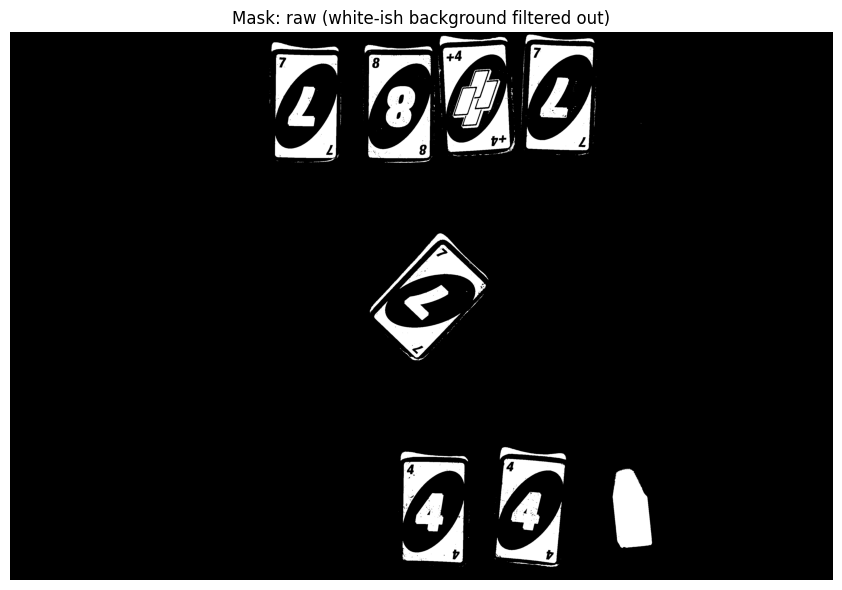

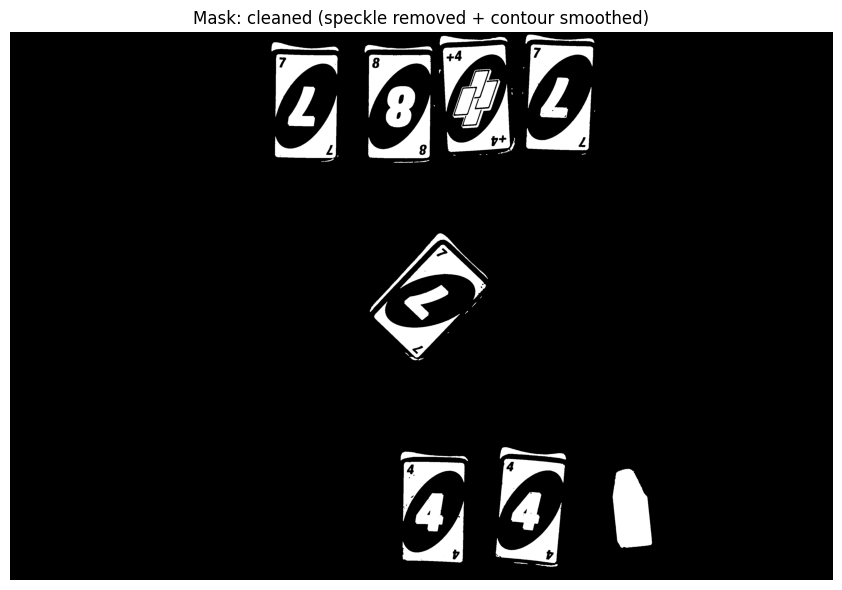

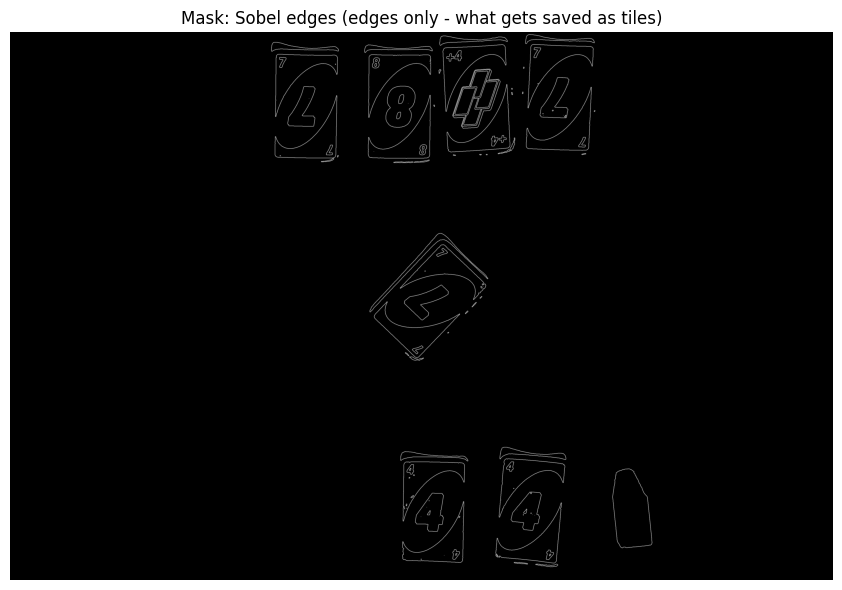

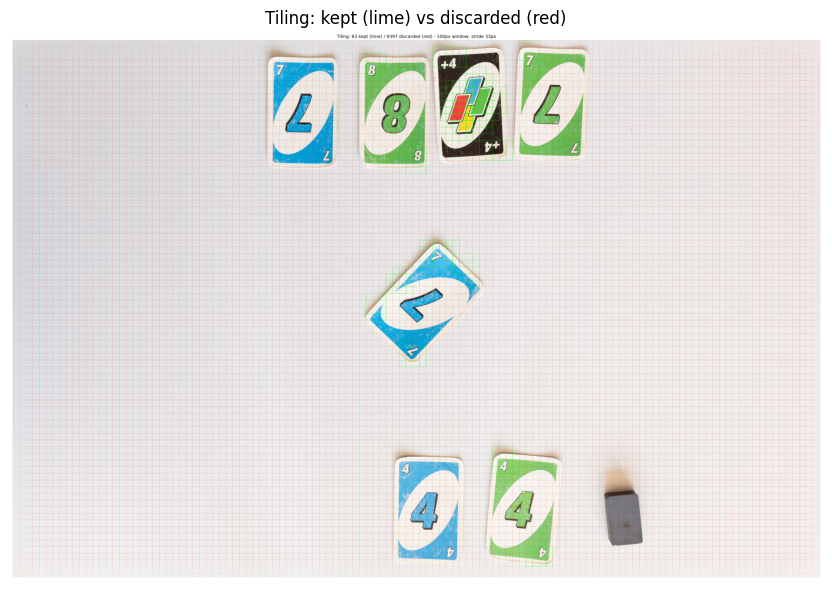

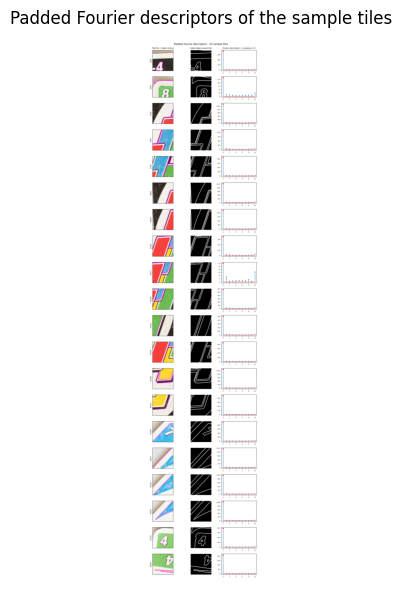

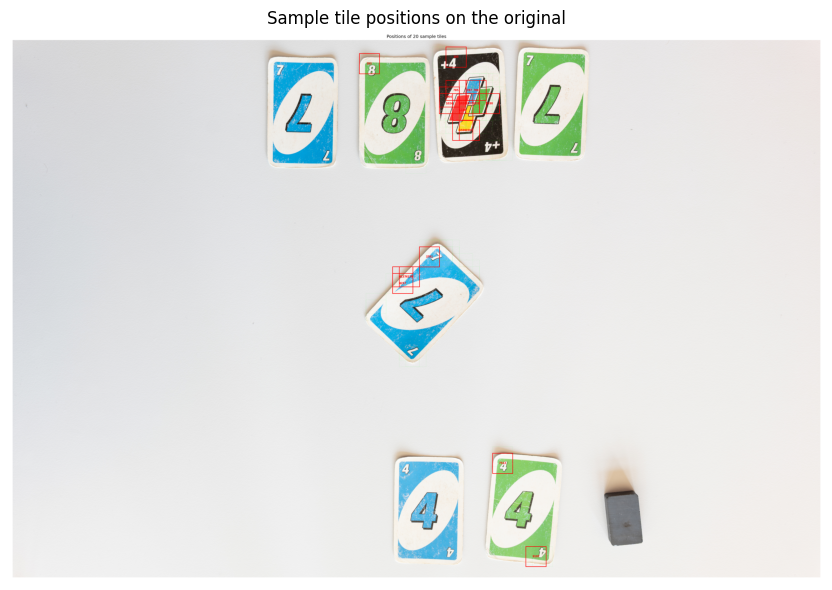

In [ ]:
#!/usr/bin/env python3
"""
main.py
=======
Entry point for the UNO card tiling pipeline.
Configure the parameters below, then run:  python main.py
"""

# ---- imports ----
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tiling import tile_image

# ---- default window and convolution params ----
TILE_SIZE = 75           # square convolution window size, in px, 75 by default
OVERLAP   = 2.0 / 3.0     # fractional overlap -> stride = round(TILE_SIZE * (1 - OVERLAP))

# ---- default threshold params ----
SAT_MAX             = 40    # HSV saturation below this -> candidate white-ish background
VAL_MIN             = 180   # HSV value above this      -> candidate white-ish background
EDGE_KEEP_FRAC = 0.1  # keep a tile if >= 3% of its Sobel tile is edge pixels 10% not bad
EDGE_THRESH    = 20    # Sobel intensity above which a pixel counts as an edge

# ---- sampling / output params ----
N_SAMPLES   = 20        # how many kept tiles to sample for the descriptor figure
SEED        = 42        # RNG seed for reproducible sampling
SAVE_SOURCE = "sobel"   # saved tiles are the Sobel edge map ("sobeled" mask)
FD_LENGTH   = 11        # n_samples for the padded Fourier descriptors

# ---- path to image ----
IMAGE_PATH = "./data/train_images/L1000779.jpg"
OUTDIR     = "./tile/"   # set to None to write next to the image

# ---- call the tiling function on image ----
if __name__ == "__main__":
    results = tile_image(
        image_path=IMAGE_PATH,
        tile_size=TILE_SIZE,
        overlap=OVERLAP,
        sat_max=SAT_MAX,
        val_min=VAL_MIN,
        edge_keep_frac=EDGE_KEEP_FRAC,
        edge_thresh=EDGE_THRESH,
        n_samples=N_SAMPLES,
        seed=SEED,
        outdir=OUTDIR,
        save_source=SAVE_SOURCE,
        fd_length=FD_LENGTH,
    )

    print(f"\nDone. Kept {results['n_kept']} / {results['n_tiles']} tiles "
          f"({results['n_discarded']} discarded as background).")
    print(f"Fourier descriptors: array shape {results['descriptors'].shape} "
          f"(complex, one row per sampled tile).")

    # ---- display: mask chain + the tiling outputs ----
    def show(path, title, cmap=None):
        img = mpimg.imread(path)
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
        fig.tight_layout()

    # the mask chain: raw -> cleaned -> Sobel edges
    show(results["mask_raw_path"], "Mask: raw (white-ish background filtered out)",
         cmap="gray")
    show(results["mask_clean_path"], "Mask: cleaned (speckle removed + contour smoothed)",
         cmap="gray")
    show(results["mask_path"], "Mask: Sobel edges (edges only - what gets saved as tiles)",
         cmap="gray")
    # tiling + descriptors + positions
    show(results["grid_path"], "Tiling: kept (lime) vs discarded (red)")
    show(results["samples_path"], "Padded Fourier descriptors of the sample tiles")
    show(results["map_path"], "Sample tile positions on the original")

    plt.show()